In [68]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [69]:
# Загрузка изображения и конвертация в градации серого
image_path = 'people_me.jpg'
image = cv2.imread(image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

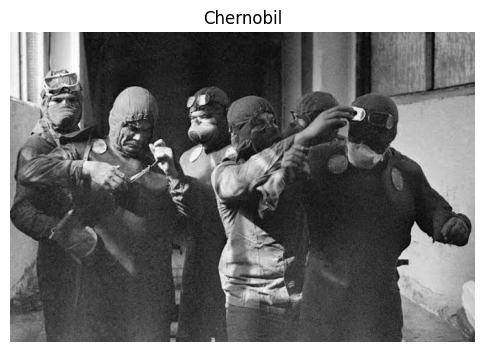

In [70]:
plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.title("Chernobil")
plt.axis('off')
plt.show()

In [71]:
#1 Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

#2 Постоянный шум (Соль и перец)
noise = np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

bg_image = np.ones(image_gray.shape, np.uint8) * 128
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255



In [72]:
# Накладываем шум на фото
image_noise_gauss = cv2.add(image_gray, noise_gauss)

image_noise_sp = image_gray.copy()
image_noise_sp[zeros_pixel] = 0
image_noise_sp[ones_pixel] = 255

# Используем фильтры

# 1 Фильтр Гаусса (ядро 5х5)
blur_gauss_G = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
blur_sp_G = cv2.GaussianBlur(image_noise_sp, (5, 5), 0)

# 2 Медианный фильтр (ядро 5)
median_gauss = cv2.medianBlur(image_noise_gauss, 5)
median_sp = cv2.medianBlur(image_noise_sp, 5)

# 3 Билатеральный фильтр (диаметр 9, сигмы 75)
bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
bilateral_sp = cv2.bilateralFilter(image_noise_sp, 9, 75, 75)

# 4 Фильтр  NLM (сила фильтрации 30)
nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, None, 30, 7, 21)
nlm_sp = cv2.fastNlMeansDenoising(image_noise_sp, None, 30, 7, 21)

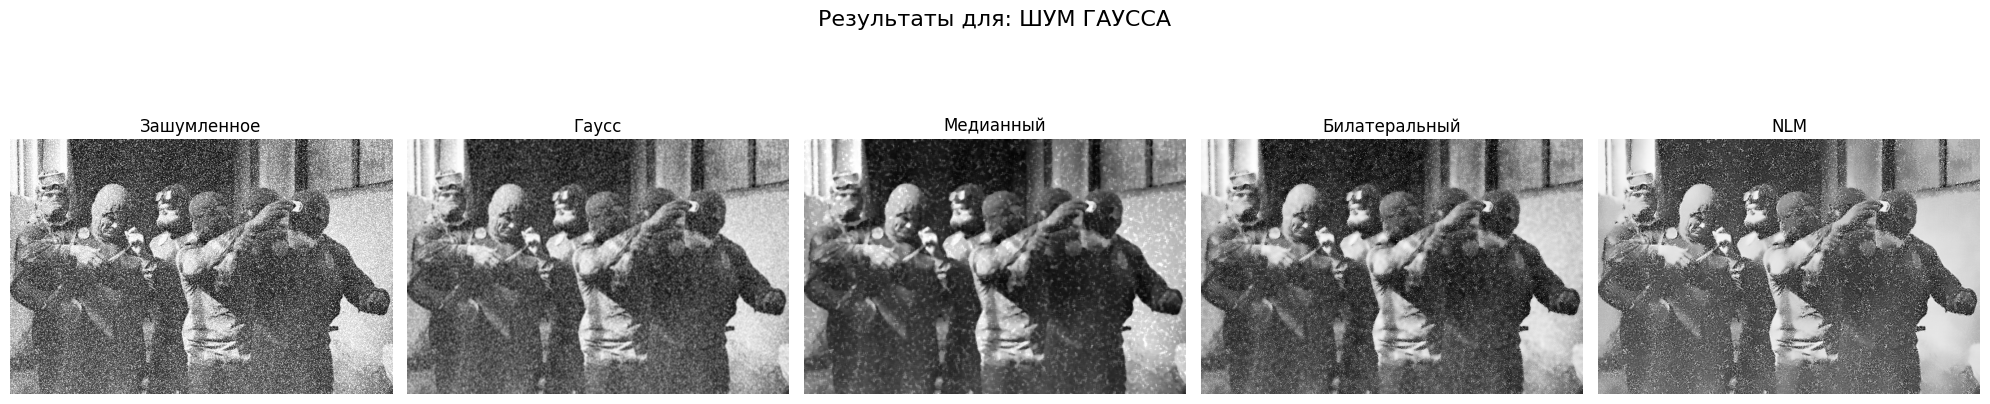

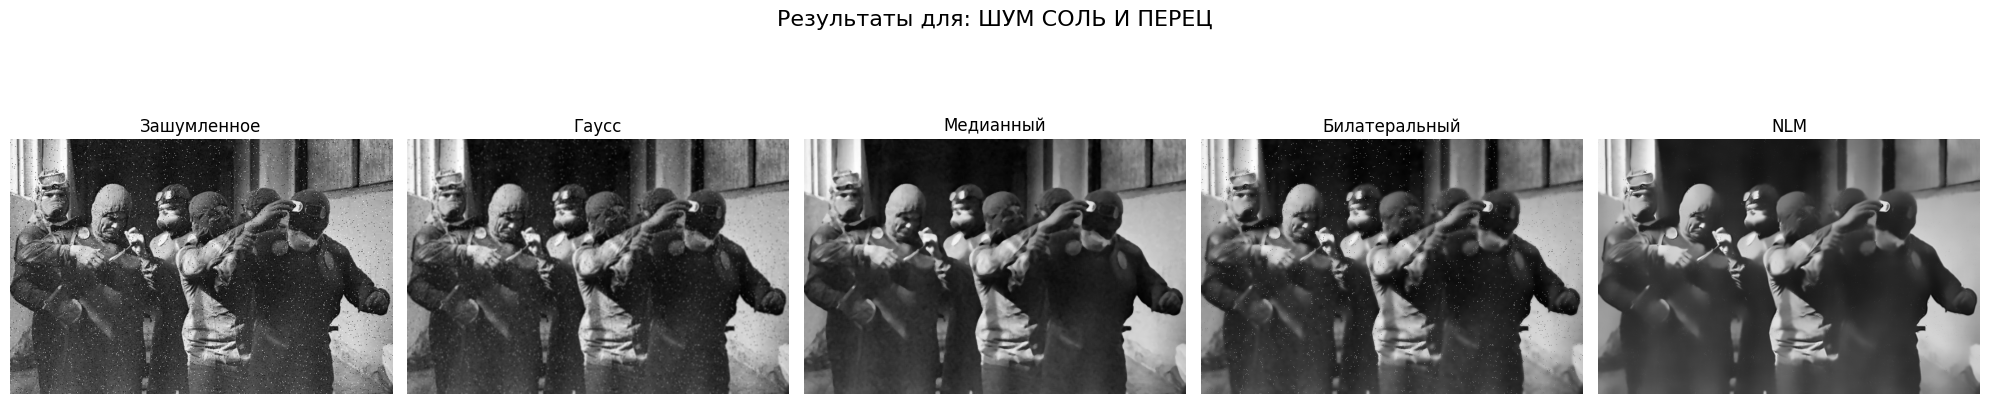

In [73]:
def show_filters(noisy_img, f_gauss, f_median, f_bilateral, f_nlm, noise_name):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f'Результаты для: {noise_name}', fontsize=16)

    images = [noisy_img, f_gauss, f_median, f_bilateral, f_nlm]
    titles = ['Зашумленное', 'Гаусс', 'Медианный', 'Билатеральный', 'NLM']

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Отрисовка
show_filters(image_noise_gauss, blur_gauss_G, median_gauss, bilateral_gauss, nlm_gauss, "ШУМ ГАУССА")
show_filters(image_noise_sp, blur_sp_G, median_sp, bilateral_sp, nlm_sp, "ШУМ СОЛЬ И ПЕРЕЦ")

### Вывод по результатам фильтрации:

1. **Для постоянного шума ("соль и перец"):**
Лучший результат фильтрации показал **Медианный фильтр**. Он отлично удаляет черные и белые точки, сохраняя при этом резкость границ объектов изображения. Остальные фильтры лишь размывают точки, превращая их в пятна или оставляют такой же шум.

2. **Для шума Гаусса:**
Лучший результат показал **Медианный**, так как он отлично восстанавливает однородные участки текстуры. **Билатеральный фильтр** также хорош.(на самом деле на каждой фотогрфии по-разному,это все индивидуально)